No enhancement ET downwind of roughness in Baldocchi  (feature of the model)

### Boundary conditions

- The z0 values over the desert and the field respectively were taken as 0.005 m and 0.05 m. 
The surface roughness for heat and moisture (z0r) was assumed to be zo/5 
 
𝑅_𝑛−𝐺_𝑠=𝐿𝐸+𝐻

𝑅_𝑛= (1 − 𝛼_𝑠 ) 𝑅_𝑠𝑖+𝑅_𝑖𝑙−𝜖_𝑠 𝜎𝑇_𝑠^4

𝛼_𝑠  depends on soil moisture

#### Variables
- $h$ = actual canopy height
- $d = 2/3*h$
- $z$ =  zero plane displacement

Mixing layer model: takes into account canopy sublayer effects,
 above d, no attached sublayer to ground. 
The roughness sublayer is the transition region between d and h. 
In this region, eddies are constant, because wakes, eddies; canopy creates own regime: flow inside canopy is slow and doesn't scale with distance from boundary
  
## Questions:
- What is the canopy height?
- What about the step change in roughness.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import numpy as np
sys.path.append("../src")
for mod in ["sutton_functions"]:
    if mod in sys.modules:
            del sys.modules[mod]
            
from sutton import *

In [2]:
import xarray as xr
ds = xr.open_dataset("../data/data_stream-oper_stepType-instant.nc", engine='h5netcdf')

lat = ds['latitude'].values
lon = ds['longitude'].values

# Coordinates of interest
lat_point = 45.6667
lon_point = -119.6667

# Find the closest indices
lat_idx = (np.abs(lat - lat_point)).argmin() + 1
lon_idx = (np.abs(lon - lon_point)).argmin() + 1

# Extract data at the closest point
data_at_point = ds.isel(latitude=lat_idx, longitude=lon_idx)


In [3]:
# # Project imports
# from sutton import (
#     Params,
#     thomas,
#     our_central_difference,
#     integrate_T_implicit,
#     integrate_H2O_implicit,
#     stability,
#     saturation_vapor_pressure,
#     vapor_concentration_RH,
# )
# print("sutton imports ready")

In [4]:
from sutton import Params, saturation_vapor_pressure, vapor_concentration_RH
import numpy as np

def get_params(fallow_fraction = 0.5, fallow_length = 1000, 
               T_sc = 30, T_sf = 50, T_a = 18, 
               RH_c = 43, RH_f = 20, RH_a = 18,
               h = 2.3, zom_f = 0.005, zom_c = 0.05,
               SW_in = 400, e_f = 0.95, e_c = 0.95, e_a = .8, 
               alpha_c = 0.22, alpha_f = 0.22, lm_option = 'kz'):
    p = Params(fallow_length=fallow_length, fallow_fraction=fallow_fraction,
               T_sc=T_sc, T_sf=T_sf, T_a=T_a, RH_c=RH_c, RH_f=RH_f, RH_a=RH_a,
               h=h, zom_f=zom_f, zom_c=zom_c, SW_in=SW_in, e_f=e_f, e_c=e_c, e_a=e_a,
               alpha_c=alpha_c, alpha_f=alpha_f, lm_option=lm_option)
    return p.to_dict()

In [5]:
def get_lm(k,h,z, option = 'kz'):
    """
    mixing length option
    """
    d = 2/3*h
    
    if option == 'kz':
        lm = k*z
    else:
        a = 1
        lm = k*z   #  k*a*(h/3)
        lm[z < a*(h - d)] = k*a*h/3 
        # mixing length continuous, persist 1/2 canopy
        # height roughness sublayer effects.
        # z > 3/2 h mixing length model is working
    
    return lm



In [6]:
# def integrate_H2O_implicit(n, m, dx, dz, A, B, C, Qup, Q_s, Q_a):
#     """
#     This function computes the coefficients
#       of the second-order system of variable s(t+dt)
#       formed by the (known) profile values at s(t).
      
#       The system is AA1 d2s/dz2 + AA2 ds/dz + AA3 s=AA4
#       The coefficients in AA4 are used from s(t)
#       The coefficients in AA1 are mainly the diffusion
#       The coefficients in AA2 include advection
#       The coefficients in AA3 include advection + s(t+dt)  
#     """
#     # Setup the tridiagonal solver for mean H2O concentration
#     AA1 = - A * B
#     AA2 = - C * B
#     AA3 = 1 / dx
#     AA4 = Qup / dx
    
#     upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
#     dia = (-2 * AA1 / (dz ** 2) + AA3)
#     lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))
    
#     co = np.zeros(m)
#     co[:] = AA4

#     # Ensure the boundary conditions are state, not flux
#     lod[0] = 0
#     lod[m-1] = 0
#     dia[0] = 1
#     dia[m-1] = 1
#     upd[0] = 0
#     upd[m-1] = 0

#     # Enforce surface and upper H2O concentration

#     co[0] = Q_s
#     co[m-1] = Q_a

#     # Call the tridiagonal solver
#     Q1 = thomas(lod, dia, upd, co)

#     dQdz = our_central_difference(Q1, dz)

#     # Fq = - A * dQdz
    
    
#     return Q1, Fq


# def integrate_T_implicit(n, m, dx, dz, A, B, C, Tup, Ts, Ta):
#     """
#     This function computes the coefficients
#       of the second-order system of variable s(t+dt)
#       formed by the (known) profile values at s(t).
      
#       The system is AA1 d2s/dz2 + AA2 ds/dz + AA3 s=AA4
#       The coefficients in AA4 are used from s(t)
#       The coefficients in AA1 are mainly the diffusion
#       The coefficients in AA2 include advection
#       The coefficients in AA3 include advection + s(t+dt)  
#     """
#     # Setup the tridiagonal solver for mean H2O concentration
#     AA1 = - A * B
#     AA2 = - C * B
#     AA3 = 1 / dx
#     AA4 = Tup / dx
    
#     upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
#     dia = (-2 * AA1 / (dz ** 2) + AA3)
#     lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))
    
#     co = np.zeros(m)
#     co[:] = AA4

#     # Ensure the boundary conditions are state, not flux
#     lod[0] = 0
#     lod[m-1] = 0
#     dia[0] = 1
#     dia[m-1] = 1
#     upd[0] = 0
#     upd[m-1] = 0

#     # Enforce surface and upper H2O concentration
#     co[0] = Ts
#     co[-1] = Ta

#     # Call the tridiagonal solver
#     T1 = thomas(lod, dia, upd, co)
#     dTdz = our_central_difference(T1, dz)
    
#     FT = - A * dTdz 
#     return T1, FT


def vapor_concentration_RH( T, RH = 100):
    """
    Calculate the vapor concentration (in g/m³) for a given 
    relative humidity (RH) and temperature (T in °C).
    
    Parameters:
    - RH (float): Relative humidity as a fraction (e.g., 0.5 for 50%).
    - T (float): Temperature in degrees Celsius.
    
    Returns:
    - float: Vapor concentration in g/m³.
    """
    # Constants
    M_w = 18.015  # molar mass of water vapor in g/mol
    R = 8.314  # universal gas constant in J/(mol*K)
    
    # Calculate the saturation vapor pressure (Pa)
    e_s = 6.1094 * math.exp((17.625 * T) / (T + 243.04))*100

    # Actual vapor pressure (Pa)
    e = RH/100 * e_s
    
    # Vapor concentration (g/m³)
    C = (e * M_w) / (R * (T + 273.15))
    
    return C

def get_e_sat(T) :
     
    #  T (float): Temperature in degrees Celsius.    
    e_s = 6.1094 * math.exp((17.625 * T) / (T + 243.04))*100
    
    return e_s

def vapor_concentration(es, T):
    # Constants
    M = 18.015  # Molar mass of water in g/mol
    R = 8.314  # Universal gas constant in J/(mol·K)
    
    # Water vapor concentration calculation
    rho = (es * M) / (R * T)
    return rho


In [36]:
def get_params(fallow_fraction = 0.5, fallow_length = 1000, 
                T_sc = 30, T_sf = 50, T_a = 18, 
                Q_a = 18, Q_c = 43, Q_f = 20,
                h = 1, zom_f = 0.05,
                zom_c = 0.05, 
                SW_in = 400, 
                e_f = 0.95, e_c = 0.95, e_a = .8,
                alpha_c = 0.22, alpha_f = 0.22,
                lm_option = 'kzm', adj_grid = 0
              ):
    
    # Flat parameter dictionary
    params = {
        "k": 0.4,                # von Karman constant        
        "zom_f": zom_f,          # Momentum roughness length (m)
        "zom_c": zom_c,          # Momentum roughness length (m)        
        'h' : h,
        "Lx": 20000,            # Domain length in x-direction
        "Hmax": 100,            # Maximum height

        "fallow_fraction": fallow_fraction,
        "fallow_length" : fallow_length,
        "dz": 0.2,
        "dx": 5,
        'Q_c' : Q_c,
        'Q_f' : Q_f,
        'Q_a' : Q_a,        
        'T_sc' : T_sc,  # Cultivated temperature
        'T_sf' : T_sf,  # Fallow temperature
        
        'SW_in' : SW_in,
        'T_a' : T_a,  # Atmos temperature
        'e_a' : e_a,
        'e_f' : e_f,
        'e_c' : e_c,
        'alpha_c' : alpha_c,
        'alpha_f' : alpha_f,  
        'lm_option' : lm_option,
        'adj_grid' : adj_grid      
    }
    Ubar_4 = 3.76
    Ubar_4 = 3.76*2

    ustar_f = 0.4*Ubar_4/np.log(4/zom_f)    # Friction velocity (m/s)
    ustar_c = 0.4*Ubar_4/np.log(4/zom_c)

    params['xmin'] = 0
    params['ustar_f'] = ustar_f
    params['ustar_c'] = ustar_c    
    params['xmax'] = params['Lx']
    params['zmin'] = params['zom_f']
    params['zmax'] = params['Hmax']
    params['patch_size'] = int(params['fallow_length']/params['dx'])
    
    if fallow_fraction > 0:
        params['gap_size'] = int(params['patch_size']*(1- fallow_fraction)/fallow_fraction)
    else:
        params['gap_size'] = 0
        
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
    nz = len(z)
    x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])
    nx = len(x)   
    
    params['nx'] = nx
    params['nz'] = nz

    return params


In [37]:
def uniform_Q(params):
    """
    The function computes an implicit solution for water vapor concentration and
    flux in a turbulent boundary layer.
    
    - Uses an implicit finite-difference method for solving the transport equation.
    - Implements mixing length theory to define eddy diffusivity.
    - Marches along the x-direction to iteratively solve for the concentration field.

    """
    nx = params['nx']
    nz = params['nz']    
    dx = params['dx']    
    dz = params['dz']  
    zmax = params['zmax']      
    k = params['k']          
    
    ustar_f = params['ustar_f']
    zom_f = params['zom_f']  
    zoh_f = params['zom_f']/5    
    
    ustar_c = params['ustar_c']
    zom_c = params['zom_c']  
    zoh_c = params['zom_c']/5
    
    Q_f = params['Q_f']
    Q_c = params['Q_c']
    Q_a = params['Q_a']
    h = params['h']
    lm_option = params['lm_option']
    adj_grid = params['adj_grid']

    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    LE_f = ustar_f*k*(Q_f - Q_a)/np.log(zmax/zoh_f)
    Qup = Q_f - LE_f/(k*ustar_f)*np.log(z/zoh_f)
    
    LE_c = ustar_c*k*(Q_c - Q_a)/np.log(zmax/zoh_c)
    Qdown = Q_c - LE_c/(k*ustar_c)*np.log(z/zoh_c)    
    
    U = (ustar_c / k) * np.log(z / zom_c)
    
    lm = get_lm(k, h, z, lm_option)    
    
    # Setup coefficients for the implicit scheme
    A = lm * ustar_c
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Upwind wv concentrations and fluxes
    Q1 = Qup
    Q_uniform = np.zeros((nx , nz))
    Q_uniform[0, :] = Q1
    FluxQ_uniform = np.zeros((nx , nz))

    # Begin downwind calculations by marching along x
    for i in range(nx):
        Q2, Fq = integrate_H2O_implicit(nx, nz, dx, dz, A, B, C, Q1, Qdown[0], Q_a, z)
        Q_uniform[i, :] = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2
        
    return Q_uniform, FluxQ_uniform  # g m⁻³,  g m⁻² s⁻¹ (mass flux)


def uniform_T(params):
    """
    The function solves an implicit equation for temperature transport in a turbulent boundary layer.
    
    - Uses an implicit finite-difference method to solve the advection-diffusion equation.
    - Mixing length theory is applied to define eddy diffusivity.
    - Marches along the x-direction to iteratively compute the temperature field.
    
    """
    nx = params['nx']
    nz = params['nz']    
    dx = params['dx']        
    dz = params['dz']        
    k = params['k']              
    zmax = params['zmax']
    
    ustar_f = params['ustar_f']
    zom_f = params['zom_f']  
    zoh_f = params['zom_f']/5    
    ustar_c = params['ustar_c']
    zom_c = params['zom_c']  
    zoh_c = params['zom_c']/5
    
    T_sf = params['T_sf']    
    T_sc = params['T_sc']
    T_a = params['T_a']
    h = params['h']    
    
    lm_option = params['lm_option']
    adj_grid = params['adj_grid']
    
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])  
    
    wT = - (T_a - T_sf)*k*ustar_f/np.log(zmax/zoh_f)      # K m/s
    Tup = T_sf - wT/(k*ustar_f)*np.log(z/zoh_f)

    wT_down = -(T_a - T_sc)*k*ustar_c/np.log(zmax/zoh_c)  # K m/s    
    Tdown = T_sc - wT_down/(k*ustar_c)*np.log(z/zoh_c)

    U = (ustar_c / k) * np.log(z / zom_c)    
    
    # Setup coefficients for the implicit scheme
    lm = get_lm(k, h, z, lm_option)       
    A = lm * ustar_c
    B = 1.0 / U
    C = our_central_difference(A, dz)

    # Upwind wv concentrations and fluxes
    T1 = Tup
    T_uniform = np.zeros((nx , nz))
    T_uniform[0, :] = T1
    FluxT_uniform = np.zeros((nx , nz))

    # Begin downwind calculations by marching along x
    for i in range(nx):
        T2, FT = integrate_T_implicit(nx, nz, dx, dz, A, B, C, T1, Tdown[0], T_a,z)
        T_uniform[i, :] = T2
        FluxT_uniform[i, :] = FT
        T1 = T2


    return T_uniform, FluxT_uniform


In [38]:
# ── Boundary conditions from Baldocchi and Rao (1995) ──────────────────────
# Site: potato field adjacent to sagebrush desert, eastern Oregon
# Observation days: June 3 (Day 154) and June 13 (Day 164), 1992

# Kinematic surface fluxes (divide energy fluxes by appropriate constants):
#   LE  (W m⁻²) → kinematic mass flux (g m⁻² s⁻¹) by dividing by Lv (J g⁻¹)
#   SH  (W m⁻²) → kinematic heat flux  (K m s⁻¹)  by dividing by ρ·cp
LE_f = 100/(2260)       # fallow (desert): LE = 100 W m⁻²
SH_f = 350/(1005*1.2)   # fallow (desert): H  = 350 W m⁻²

LE_c = 500/(2260)       # crop (potato):   LE = 500 W m⁻²
SH_c = 50/(1005*1.2)    # crop (potato):   H  =  50 W m⁻²

# Observed net radiation and ground heat flux (W m⁻²)
Rn_f = 480   # fallow net radiation
Rn_c = 580   # crop net radiation
G  = 30      # ground heat flux

# Meteorological forcing
SW = 700             # incoming shortwave radiation (W m⁻²)
T_a = 16 + 273.15   # air temperature (K) — converted from 16 °C
Q_a = 5              # ambient water-vapour concentration (g m⁻³)

# Surface emissivities
epsilon_a = 0.9    # atmosphere
epsilon_f = 0.95   # fallow / desert
epsilon_c = 0.95   # crop / potato

# ── Build parameter dict ───────────────────────────────────────────────────
# h = 2.3 m (potato canopy height), equal z0m for both surfaces (0.05 m)
params = get_params(h = 2.3, zom_f = 0.05,
               zom_c = 0.05, SW_in = SW, 
               e_f = epsilon_f, e_c = epsilon_c, e_a = epsilon_a,            
               lm_option = 'kz', adj_grid = 0)

# ── Extract derived grid & turbulence quantities ──────────────────────────
z_h = params['Hmax']          # domain top (m)
zom_c = params['zom_c']       # crop momentum roughness (m)
zom_f = params['zom_f']       # fallow momentum roughness (m)
# Scalar (heat/moisture) roughness = z0m / 5  (common parameterisation)
zoh_c = params['zom_c']/5
zoh_f = params['zom_f']/5
k = params['k']               # von Kármán constant
ustar_f = params['ustar_f']   # fallow friction velocity (m s⁻¹)
ustar_c = params['ustar_c']   # crop friction velocity (m s⁻¹)

# Vertical grid
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
              params['dz'])

# ── Solve for surface temperatures & albedos symbolically ─────────────────
# Six unknowns (T_sf, T_sc, Q_f, Q_c, alpha_f, alpha_c) from six equations:
#   eq1-eq2: net radiation balance at each surface,  Rn = SW(1−α) + ε_a σ T_a⁴ − ε_s σ T_s⁴
#   eq3-eq4: neutral log-law for temperature,        T_s − T_a = (H / k u*) ln(z_h / z_ref)
#   eq5-eq6: neutral log-law for moisture,            Q_s − Q_a = (LE / k u*) ln(z_h / z_ref)
from sympy import symbols, Eq, solve

sigma_sb = 5.67*1e-8   # Stefan–Boltzmann constant (W m⁻² K⁻⁴)

T_sf, T_sc, Q_f, Q_c, alpha_f, alpha_c = symbols(
    'T_sf T_sc Q_f Q_c alpha_f alpha_c')

level = 0   # reference height index for the log-law (lowest grid level)

# Radiation balance: incoming SW + atmospheric LW − emitted LW = Rn
eq1 = Eq(SW*(1-alpha_f) + epsilon_a*sigma_sb*T_a**4 - epsilon_f*sigma_sb*T_sf**4, Rn_f )
eq2 = Eq(SW*(1-alpha_c) + epsilon_a*sigma_sb*T_a**4 - epsilon_c*sigma_sb*T_sc**4, Rn_c )

# Neutral log-law for temperature (K) at each surface
eq3 = Eq(T_sf - T_a, 1/(k*ustar_f)*SH_f*np.log(z_h/(z[level])))
eq4 = Eq(T_sc - T_a, 1/(k*ustar_c)*SH_c*np.log(z_h/ z[level]))

# Neutral log-law for moisture (g m⁻³) at each surface
eq5 = Eq(Q_f - Q_a, 1/(k*ustar_f)*LE_f*np.log(z_h/(z[level])))
eq6 = Eq(Q_c - Q_a, 1/(k*ustar_c)*LE_c*np.log(z_h/(z[level])))

# Solve the 6×6 system for all unknowns
solution = solve((eq1, eq2, eq3, eq4, eq5, eq6), 
                 (T_sf, T_sc, Q_f, Q_c, alpha_f, alpha_c  ))

# ── Extract symbolic solution ──────────────────────────────────────────────
T_sf, T_sc, Q_f, Q_c, alpha_f, alpha_c  =  solution[0]

print("── Solved boundary conditions (raw, at z_ref = z[{0}] = {1:.2f} m) ──".format(level, float(z[level])))
print(f"  T_sf = {float(T_sf):.2f} K,  T_sc = {float(T_sc):.2f} K")
print(f"  Q_f  = {float(Q_f):.3f} g/m³,  Q_c  = {float(Q_c):.3f} g/m³")
print(f"  α_f  = {float(alpha_f):.4f},  α_c  = {float(alpha_c):.4f}")

# ── Convert temperatures from K to °C ─────────────────────────────────────
T_a = T_a - 273.15
T_sf = T_sf - 273.15
T_sc = T_sc - 273.15

print(f"\n── After K → °C conversion ──")
print(f"  T_a  = {float(T_a):.2f} °C")
print(f"  T_sf = {float(T_sf):.2f} °C,  T_sc = {float(T_sc):.2f} °C")

# ── Rescale from z_ref to z0h reference height ────────────────────────────
# The sympy solve used z[level] as the reference height in the log-law.
# Rescale T and Q so that the log profiles are referenced to z0h instead,
# preserving the same flux:  φ_s = (φ_ref − T_a) · ln(z_h/z0h) / ln(z_h/z_ref) + T_a
T_sf = np.log(z_h/zoh_f)/np.log(z_h/z[level])*(T_sf - T_a) + T_a
T_sc = np.log(z_h/zoh_c)/np.log(z_h/z[level])*(T_sc - T_a) + T_a

Q_f = np.log(z_h/zoh_f)/np.log(z_h/z[level])*(Q_f - Q_a) + Q_a
Q_c = np.log(z_h/zoh_c)/np.log(z_h/z[level])*(Q_c - Q_a) + Q_a

print(f"\n── After rescaling to z0h reference ({zoh_f:.4f} m / {zoh_c:.4f} m) ──")
print(f"  T_sf = {float(T_sf):.2f} °C,  T_sc = {float(T_sc):.2f} °C")
print(f"  Q_f  = {float(Q_f):.3f} g/m³,  Q_c  = {float(Q_c):.3f} g/m³")
print(f"  α_f  = {float(alpha_f):.4f},  α_c  = {float(alpha_c):.4f}")


LW_out_c = epsilon_c*sigma_sb*(T_sc)**4
LW_in_c = epsilon_a*sigma_sb*(T_a)**4

Rn_c = (1 - alpha_c)*SW  + LW_in_c - LW_out_c

print(f"Incoming longwave radiation = {float(LW_in_c):.2f} W/m2")
print(f"Outgoing longwave radiation = {float(LW_out_c):2f} W/m2")

── Solved boundary conditions (raw, at z_ref = z[0] = 0.25 m) ──
  T_sf = 295.48 K,  T_sc = 290.05 K
  Q_f  = 5.966 g/m³,  Q_c  = 9.828 g/m³
  α_f  = 0.2373,  α_c  = 0.1364

── After K → °C conversion ──
  T_a  = 16.00 °C
  T_sf = 22.33 °C,  T_sc = 16.90 °C

── After rescaling to z0h reference (0.0100 m / 0.0100 m) ──
  T_sf = 25.73 °C,  T_sc = 17.39 °C
  Q_f  = 6.484 g/m³,  Q_c  = 12.421 g/m³
  α_f  = 0.2373,  α_c  = 0.1364
Incoming longwave radiation = 0.00 W/m2
Outgoing longwave radiation = 0.004927 W/m2


In [39]:
params = get_params(T_sc = T_sc, T_sf = T_sf,
                    Q_c = Q_c, Q_f = Q_f,
                    T_a = T_a, Q_a = Q_a, SW_in = SW, 
                    e_f = epsilon_f,
                    e_c = epsilon_c,
                    e_a = epsilon_a,
                    alpha_f = float(alpha_f), alpha_c = float(alpha_c))
# TODO: write pretty print statement for params, includng which defaults overwritten

In [40]:
T_uniform, FluxT_uniform = uniform_T(params)
Q_uniform, FluxQ_uniform = uniform_Q(params)

SH = FluxT_uniform*1005*1.2
LE = FluxQ_uniform*2.5*1e6/1000
FluxTotal = SH + LE


In [41]:
# TODO: comment and explain code here

def get_upwind_fluxQ(params):
    """
    """
    ustar = params['ustar_f']    
    dz = params['dz']
    nz = params['nz']
    k = params['k']
    zmax = params['zmax']
    zoh = params['zom_f']/5
    h = params['h']
    nx = params['nx']     
    lm_option = params['lm_option']
    
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    k = params['k']
    Q_f = params['Q_f']
    Q_a = params['Q_a']
    
    LE_f = ustar*k*(Q_f - Q_a)/np.log(zmax/zoh)
    print (LE_f*2260)
    Qup = Q_f - LE_f/(k*ustar)*np.log(z/zoh)
    dQdz = our_central_difference(Qup, dz)

    lm = get_lm(k,h, z, lm_option)
    
    A = lm * ustar

    FluxQ_upwind = - A * dQdz
    return Qup, FluxQ_upwind

def get_upwind_fluxT(params):
    """
    """
    dz = params['dz']
    nz = params['nz']
    nx = params['nx']    
    ustar = params['ustar_f']
    zmax = params['zmax']
    zoh = params['zom_f']/5
    h = params['h']
    lm_option = params['lm_option']    
    
    z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], 
                  params['dz'])    
    
    k = params['k']
    T_sf = params['T_sf']
    T_a = params['T_a']
    Q_a = params['Q_a']        
    
    wT = - (T_a - T_sf)*k*ustar/np.log(zmax/zoh) # K m/s
    Tup = T_sf - wT/(k*ustar)*np.log(z/zoh)
    
    dTdz = our_central_difference(Tup, dz)

    ustar = params['ustar_f']
    k = params['k']

    lm = get_lm(k, h, z, lm_option)    
    A = lm * ustar

    FluxT_upwind = - A * dTdz
    


    return Tup, FluxT_upwind

Qup, FluxQ_upwind = get_upwind_fluxQ(params)
Tup, FluxT_upwind = get_upwind_fluxT(params)


100.000000000000


103.34817459199945 361.71861107199885
50.34329250993407 503.43998210893466


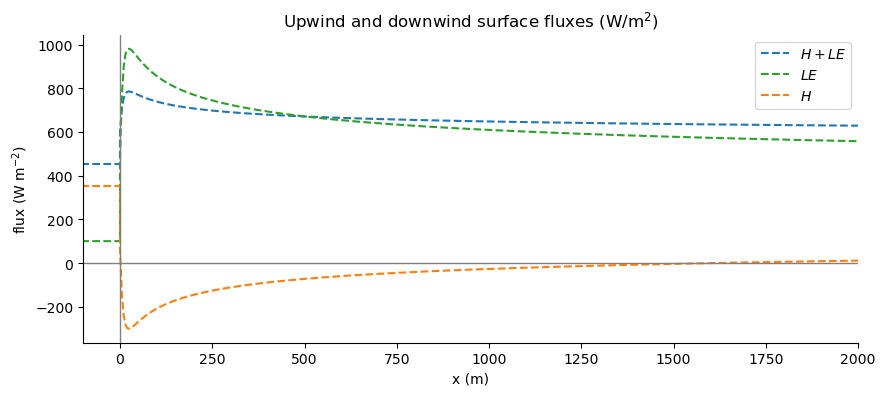

In [42]:
level = 5
plt.figure(figsize = (10, 4 ))
ax = plt.gca()

x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])
xx = np.concatenate([-np.flip(x),x])

FluxTotal_upwind = FluxQ_upwind[level]*np.ones_like(x)*2.260*1e6/1000 + \
            FluxT_upwind[level]*np.ones_like(x)*1005*1.2

FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

ax.plot(xx, FluxTotal_,  c='C0', ls='--', label='$H + LE$')

FluxQ = np.concatenate([ FluxQ_upwind[level]*np.ones_like(x), FluxQ_uniform[:, level]])
ax.plot(xx, FluxQ*2.260*1e6/1000, ls='--', c='C2', label="$LE$")

FluxT = np.concatenate([FluxT_upwind[level]*np.ones_like(x), FluxT_uniform[:,level]])
ax.plot(xx, FluxT*1005*1.2, c='C1', ls='--', label="$H$")
ax.legend()
ax.set_xlabel("x (m)")
ax.set_ylabel("flux (W m$^{-2}$)")
ax.set_title("Upwind and downwind surface fluxes (W/m$^2$)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

level = 2
print(FluxQ_upwind[level]*2260, FluxT_upwind[level]*1005*1.2)
print(FluxT_uniform[-1, level]*1005*1.2, FluxQ_uniform[-1, level]*2260)

ax.set_xlim(-100, 2000)

ax.axvline(0, c = 'grey', lw = 1)
ax.axhline(0, c = 'grey', lw = 1)

In [43]:
# TODO: write data folder readme
import pandas as pd
fig6data = pd.read_csv('../data/baldocchi1995/baldocchi1995_fig6.csv')

In [44]:
ground = params['h']*2/3 # d, height of the ground ?
params['h']

1

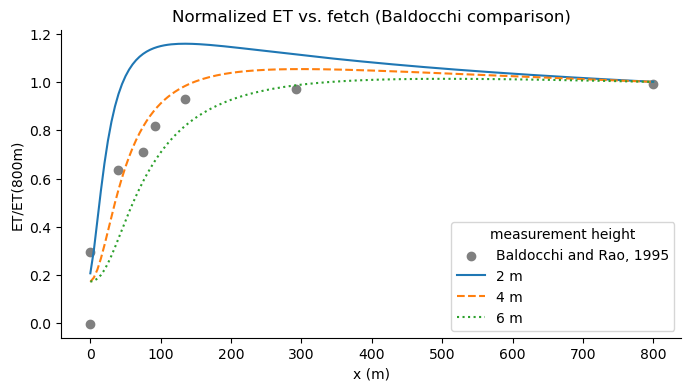

In [46]:
params['h'] = 2
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
d = params['h'] * 2/3  # zero-plane displacement

fig, ax = plt.subplots(figsize=(8, 4))

i800 = np.where(x > 800)[0][0]
ax.scatter(fig6data['x'], fig6data[' y'], c='grey', label="Baldocchi and Rao, 1995")

styles = ['-', '--', ':']
for level_h, ls in zip([2, 4, 6], styles):
    level = np.argmin(np.abs(z - (level_h + d)))
    ax.plot(x[:i800], FluxQ_uniform[:i800, level]/FluxQ_uniform[i800, level],
            ls=ls, label=f"{level_h} m")

ax.legend(title="measurement height")
ax.set_xlabel("x (m)")
ax.set_ylabel("ET/ET(800m)")
ax.set_title("Normalized ET vs. fetch (Baldocchi comparison)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# TODO: what is the height of the potato field in Rao et al.? 
# TODO: Gridded search over ustar and Ta and Qa, check height of flux tower in study


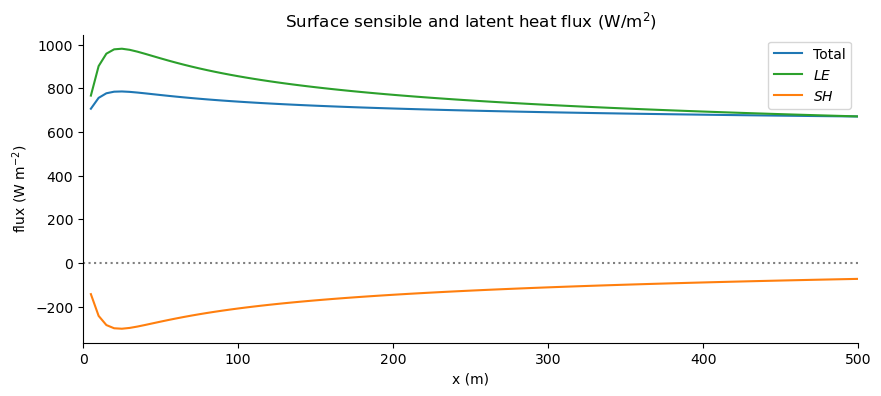

In [47]:
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

level = 5
plt.figure(figsize = (10,4))
ax = plt.gca()
ax.plot(x[1:], FluxTotal[1:, level], label='Total', c='C0')
ax.plot(x[1:], FluxQ_uniform[1:, level]*2.260*1e6/1000, label="$LE$", c='C2')
ax.plot(x[1:], FluxT_uniform[1:, level]*1005*1.2, label="$SH$", c='C1')
ax.axhline(FluxT_uniform[-1, level], ls=':', c='grey')
ax.legend()
ax.set_xlim(0, 500)
ax.set_xlabel("x (m)")
ax.set_ylabel("flux (W m$^{-2}$)")
ax.set_title("Surface sensible and latent heat flux (W/m$^2$)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# FluxTotal[level, -1]

In [48]:
params['ustar_c']

0.6864403735473554

458.93853409780036

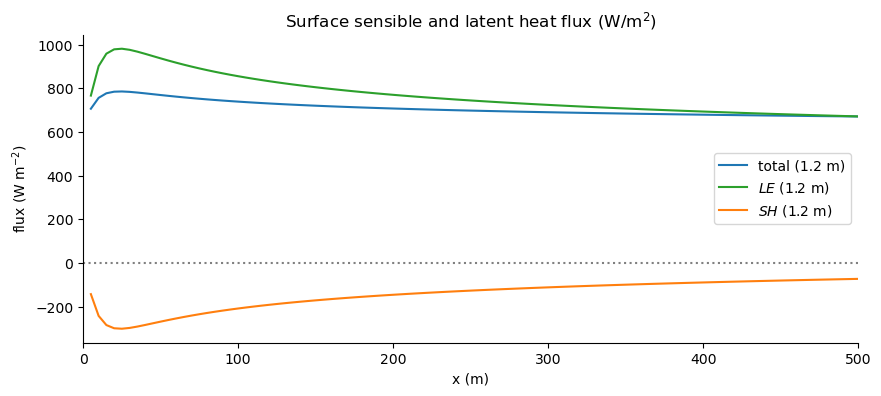

In [49]:
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

level = 5
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x[1:], FluxTotal[1:, level], label=f'total ({z[level]:.1f} m)', c='C0')
ax.plot(x[1:], FluxQ_uniform[1:, level]*2.260*1e6/1000, label=f"$LE$ ({z[level]:.1f} m)", c='C2')
ax.plot(x[1:], FluxT_uniform[1:, level]*1005*1.2, label=f"$SH$ ({z[level]:.1f} m)", c='C1')
ax.axhline(FluxT_uniform[-1, level], ls=':', c='grey')
ax.legend()
ax.set_xlim(0, 500)
ax.set_xlabel("x (m)")
ax.set_ylabel("flux (W m$^{-2}$)")
ax.set_title("Surface sensible and latent heat flux (W/m$^2$)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


FluxTotal[level, -1]

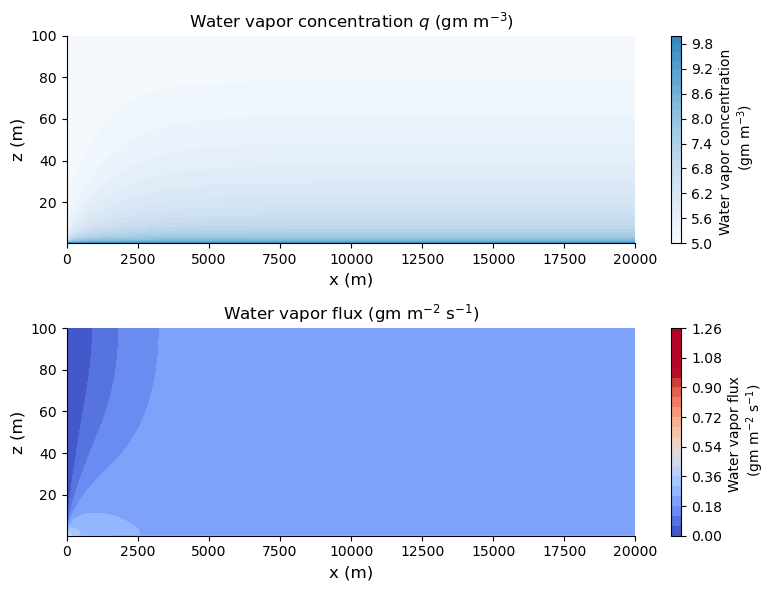

In [50]:
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

# Plot water vapor concentration and vertical flux
plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_uniform.T), 25, cmap='Blues', vmax=Q_c, vmin=Q_a)
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = plt.subplot(2, 1, 2)
plt.contourf(x, z, FluxQ_uniform.T.round(4), 20, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()


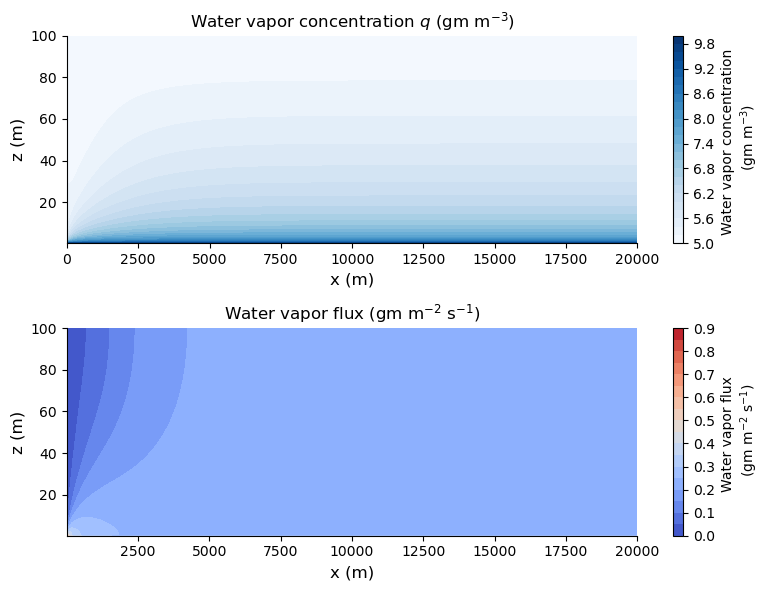

In [51]:
z = np.arange(params['zmin'] + params['dz'], params['zmax'] + params['dz'], params['dz'])
x = np.arange(params['xmin'], params['xmax'] + params['dx'], params['dx'])

# Plot water vapor concentration and vertical flux
plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_uniform.T), 25, cmap='Blues')
plt.colorbar(label='Water vapor concentration \n (gm m$^{-3}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (gm m$^{-3}$)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = plt.subplot(2, 1, 2)
plt.contourf(x[1:], z, FluxQ_uniform[1:].T.round(4), 20, cmap='coolwarm')
plt.colorbar(label='Water vapor flux \n (gm m$^{-2}$ s$^{-1}$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (gm m$^{-2}$ s$^{-1}$)', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()


In [ ]:
# Plot water vapor concentration and vertical flux
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', blues)

plt.figure(figsize=(8, 6))

ax1 = plt.subplot(2, 1, 1)
plt.contourf(x, z, (Q_uniform.T), 25, cmap=custom_cmap, vmax=13, vmin=7)
plt.colorbar(label='Water vapor concentration \n (g/m$^3$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = plt.subplot(2, 1, 2)
plt.contourf(x, z, FluxQ_uniform.T.round(4)*2260, 20, cmap='Blues')
plt.colorbar(label='Water vapor flux \n (W/m$^2$)')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# Reduce the number of tick labels for colorbars
import matplotlib.ticker as ticker
from matplotlib.colors import LinearSegmentedColormap

# Create custom colormap
blues = ['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84']
custom_cmap = LinearSegmentedColormap.from_list('custom_blues', blues)

plt.figure(figsize=(8, 5))

# Subplot 1: Water vapor concentration
ax1 = plt.subplot(2, 1, 1)
contour1 = plt.contourf(x, z[1:], Q_uniform[:, 1:].T, 25, cmap=custom_cmap, vmax=13, vmin=7)
cbar1 = plt.colorbar(contour1, label='Water vapor concentration \n (g m$^{-3}$)')
cbar1.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Subplot 2: Water vapor flux
ax2 = plt.subplot(2, 1, 2)
contour2 = plt.contourf(x, z[3:], FluxQ_uniform[:, 3:].T.round(4)*2260, 20, cmap='Blues')
cbar2 = plt.colorbar(contour2, label='Water vapor flux \n (W m$^{-2}$)')
cbar2.ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (W m$^{-2}$)', fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.show()
